# Probabilistic Occupancy Grid Map
---

*Narcís Palomeras - September 2022 - Universitat de Girona (all rights reserved)*

In this lab you are going to implement a 2D probabilistic occupancy grid map. Thge main idea is to combine robot poses and range measurements to create a map of free, occupied and unknown regions. We are going to assume that robot pose is known by some other method and, therefore, it is drift free.

The following elements are provided:

* `ground_truth_02.csv` file: contains the robot position at each time stamp.
* `laser_scan_02.csv` file: contains all range measurements gathered by the robot.
* `load_csv_files.py`: includes several auxiliar functions to load the `CSV` data as well as a `wrap_angle` function to normalize angles between $-\pi$ and $\pi$.


**Exercise 1:**

To familiarize yourself with the previous files do:

* load the data from `ground_truth_02.csv` and `laser_scan_02.csv` and check the format of the returned structures.
* plot the ground truth trajectory. 
* test the `bresenham` library ploting a line between $[-3, 5]$ to $[4, -2]$.

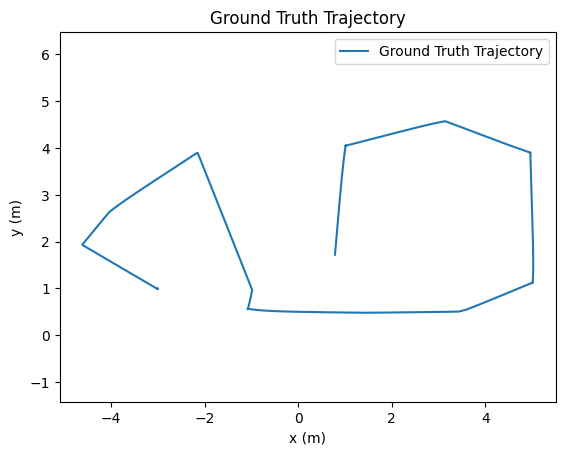

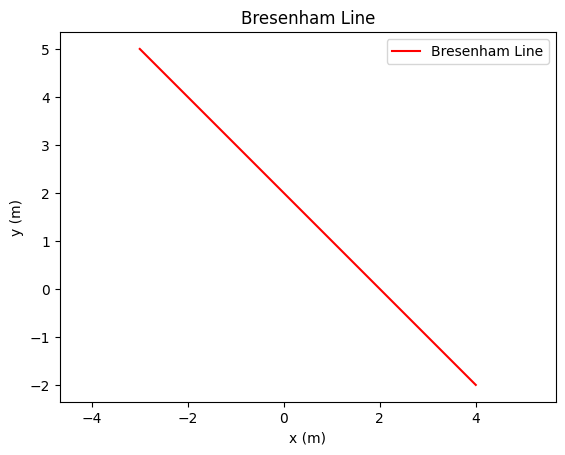

In [2]:
import numpy as np
from matplotlib import pyplot as plt
from bresenham import bresenham # pip install bresenham if required
from load_csv_files import load_encoders, load_laser_scans, load_ground_truth, wrap_angle

# LOAD DATASETS
laser_scans = load_laser_scans('laser_scan_02.csv')
stamped_gt = load_ground_truth('ground_truth_02.csv')
# Plot stamped_gt trajectory
plt.figure()
plt.plot(stamped_gt[:, 1], stamped_gt[:, 2], label="Ground Truth Trajectory")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Ground Truth Trajectory")
plt.legend()
plt.axis('equal')
plt.show()
# Plot bresenham line between [-3, 5] and [4, -2] using the bresenham function from bresenham library 
# WARNING! bresenham function returns a generator, so you need to convert it to a list to use it:
# points = list(bresenham(x1, y1, x2, y2))
Point_1 = [-3, 5]
Point_2 = [4, -2]
points = list(bresenham(Point_1[0], Point_1[1], Point_2[0], Point_2[1]))
points = np.array(points)
plt.figure()
plt.plot(points[:, 0], points[:, 1], 'r-', label="Bresenham Line")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Bresenham Line")
plt.legend()
plt.axis('equal')
plt.show()

To create a gridmap several functions and data structures are required. We have groupped them in a single class called `GridMap`. 

**Exercise 2:**

Complete the following `GridMap` class following the comments.

In [35]:
import numpy as np
from bresenham import bresenham


class GridMap:
    """
    Probabilistic occupancy grid map. 
    """
    
    # Maximum and minimum cell loggoods (is equivalen to p_max = 0.999, p_min = 0.001)
    LMAX = 6.91 
    LMIN = -6.91

    # Initialize gridmap class
    def __init__(self, center, cell_size=0.1, map_size=10):
        self.cell_size = cell_size
        self.grid = np.zeros((int(map_size/cell_size), int(map_size/cell_size))) + 0.5 # Initialize grid with 0.5 probability
        self.origin = np.array(center) - np.array([map_size, map_size])/2

    # return map
    def get_map(self):
        return self.grid

    # return origin
    def get_origin(self):
        return self.origin
    
    # Transform position wrt frame origin to cell indexes
    def __position_to_cell__(self, position):
        origin = self.get_origin()
        cell_index = np.floor((position - origin) / self.cell_size)
        cell_index = cell_index.astype(int)
        return cell_index

    # Update cell uv with probability p
    def __update_cell__(self, uv, p):
        # Check that probability p is between 0 and 1 but not 0 or 1
        if p > 0.0 and p < 1.0:
            # Compute inverse sensor model
            inverse_sensor_model = np.log(p / (1 - p))
            # Update cell and saturate between GridMap.LMIN and GridMap.LMAX 
            recursive_term = np.log(self.grid[uv[0], uv[1]]/(1 - self.grid[uv[0], uv[1]]))
            log_cell = np.clip(inverse_sensor_model + recursive_term, a_min=GridMap.LMIN, a_max=GridMap.LMAX)
            self.grid[uv[0], uv[1]] = np.exp(log_cell) / (1 + np.exp(log_cell))

    # Update all cells traversed by a ray
    def add_ray(self, ray_init_position, ray_angle, ray_range, p):
        # Compute ray final position using ray start, angle and range
        ray_final_position = np.array([ray_init_position[0] + np.cos(ray_angle) * ray_range, ray_init_position[1] + np.sin(ray_angle) * ray_range])

        # Transform intial and final position to cell indexes
        ray_init_index = self.__position_to_cell__(ray_init_position)
        ray_final_index = self.__position_to_cell__(ray_final_position)

        # Use Bresenham's algorithm to get traversed cells
        list_traversed_cells = list(bresenham(ray_init_index[0], ray_init_index[1], ray_final_index[0], ray_final_index[1]))

        # Update as no occupied (probability 1-p) the cells between start and end - 1 
        # and the last cell with probability p
        for i in range(len(list_traversed_cells) - 1):
            self.__update_cell__(list_traversed_cells[i], 1 - p) # Update the intermediate cells with probability 1 - p
        
        self.__update_cell__(list_traversed_cells[-1], p) # Update the last cell with probability p

## Dataset preparation

To create a gridmap from the robot poses and ranges it is required to have both data synchronized. 

**Exercise 3:**

Filter the `stamped_gt` data in order to have only robot positions in the time stamps in which a scan is gathered. Save the filtered poses to the `state` list. 

### pseudocode:
```
Initialize an empty list "state"
Set "i" to 0
For each "m" in "laser_scans" do
    While the first element of "stamped_gt" at index "i" is less than the first element of "m" do
        Increment "i" by 1
    End While
    Append the element at index "i" of "stamped_gt" to "state"
End For
Get the length of "state"```

In [36]:
state = []
# Filter `stamped_gt` data to have the same dimension of `laser_scans` and be synchronized with it
i = 0
for m in range(len(laser_scans)):
    while (stamped_gt[i][0] < laser_scans[m][0]):
        i += 1
    state.append(stamped_gt[i])
len(state)

1506

## Building the Probabilistic Grid Map

Now that all data is loaded and synchronized and that the `GridMap` class is ready is time to build the probabilistic grid map.

**Exercise 4:**

For each scan in the `laser_scans` list add each one of its rays in the gridmap using the `add_ray` method. You need to provide the robot position, where it gathered this beam, and the beam orientation. Be aware that the beam orientation is the composition of the robot orientation and the beam *theta*.

> Note 1: use only ranges that its value is between `min_range` and `max_range`

> Note 2: This process is quite large. Start testing with only few scans and, when it works, try with the full dataset.

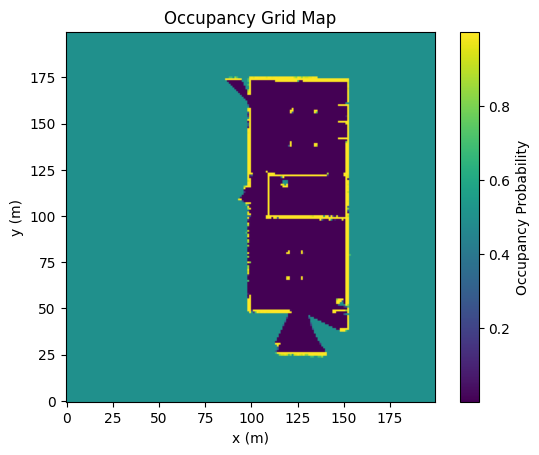

In [38]:
# Initialize data
min_range = 0.1
max_range = 5.0
gridmap = GridMap(np.array([0, 0]), 0.1, 20)

# for each scan in `laser_scans`
# - for each beam in scan
#   - if beam range is between min_range and max_range
#   - compute ray angle
#   - add ray to gridmap
for i, scan in enumerate(laser_scans):
    for j, beam in enumerate(scan[1]):
        if beam > min_range and beam < max_range:
            ray_angle = scan[2][j] + state[i][3] # scan angle + robot orientation
            gridmap.add_ray(state[i][1:3], ray_angle, beam, 0.7)
# Plot the resulting gridmap
plt.figure()
plt.imshow(gridmap.get_map(), origin='lower')
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Occupancy Grid Map")
plt.colorbar(label='Occupancy Probability')
plt.show()
# Save as a PNG image
plt.imsave('occupancy_grid_map.png', gridmap.get_map(), origin='lower')